In [1]:
import pandas as pd

df = pd.read_csv("ch4_mm_gl.csv")

# Create a proper date from year and month
df["date"] = pd.to_datetime(
    df[["year", "month"]].assign(day=1)
)

# Make date the index
df = df.set_index("date")
df = df.asfreq("MS") #tells pandas that observations occur at the start of every month

print(df.head())

            year  month   decimal  average  average_unc    trend  trend_unc
date                                                                       
1983-07-01  1983      7  1983.542  1626.05         2.39  1635.18       1.46
1983-08-01  1983      8  1983.625  1628.02         2.93  1635.67       1.39
1983-09-01  1983      9  1983.708  1638.42         2.20  1636.23       1.31
1983-10-01  1983     10  1983.792  1644.81         1.47  1636.85       1.23
1983-11-01  1983     11  1983.875  1642.60         0.82  1637.55       1.15


In [2]:
# Number of months to hold out
holdout_months = 24

# Split the data
train = df.iloc[:-holdout_months].copy()
holdout = df.iloc[-holdout_months:].copy()

# Check the split
print("Training data:")
print(train.index.min(), "to", train.index.max())
print(f"Number of observations: {len(train)}")

print("\nHoldout data:")
print(holdout.index.min(), "to", holdout.index.max())
print(f"Number of observations: {len(holdout)}")

Training data:
1983-07-01 00:00:00 to 2024-04-01 00:00:00
Number of observations: 490

Holdout data:
2024-05-01 00:00:00 to 2026-04-01 00:00:00
Number of observations: 24


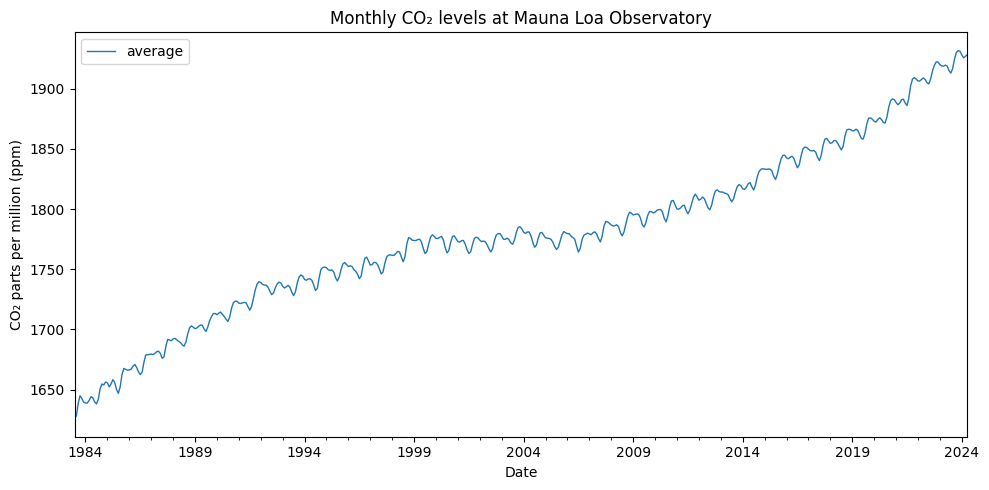

In [3]:
# Step 1: PLot the raw Series
import matplotlib.pyplot as plt

train.plot(
    y="average",
    figsize=(10, 5),
    linewidth=1
)

plt.title("Monthly CO₂ levels at Mauna Loa Observatory")
plt.xlabel("Date")
plt.ylabel("CO₂ parts per million (ppm)")
plt.tight_layout()
plt.show()

In [4]:
# Step 2: ADF test & KPSS test of raw series

from statsmodels.tsa.stattools import adfuller, kpss

# Augmented Dickey-Fuller Test
adf_result = adfuller(train["average"])

print("Augmented Dickey-Fuller (ADF) Test")
print("----------------------------------")
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"Lags Used     : {adf_result[2]}")
print(f"Observations  : {adf_result[3]}")
print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

# KPSS Test
kpss_result = kpss(train["average"], regression='c', nlags='auto')

print("\n\nKPSS Test")
print("----------------")
print(f"KPSS Statistic : {kpss_result[0]:.4f}")
print(f"p-value        : {kpss_result[1]:.4f}")
print(f"Lags Used      : {kpss_result[2]}")
print("\nCritical Values:")
for key, value in kpss_result[3].items():
    print(f"   {key}: {value:.4f}")

Augmented Dickey-Fuller (ADF) Test
----------------------------------
ADF Statistic : 0.2036
p-value       : 0.9725
Lags Used     : 13
Observations  : 476

Critical Values:
   1%: -3.4442
   5%: -2.8676
   10%: -2.5700


KPSS Test
----------------
KPSS Statistic : 3.5595
p-value        : 0.0100
Lags Used      : 12

Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390


/var/folders/qy/441jwthx2_1g0zy86by2glkh0000gn/T/ipykernel_2154/4093660534.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(train["average"], regression='c', nlags='auto')


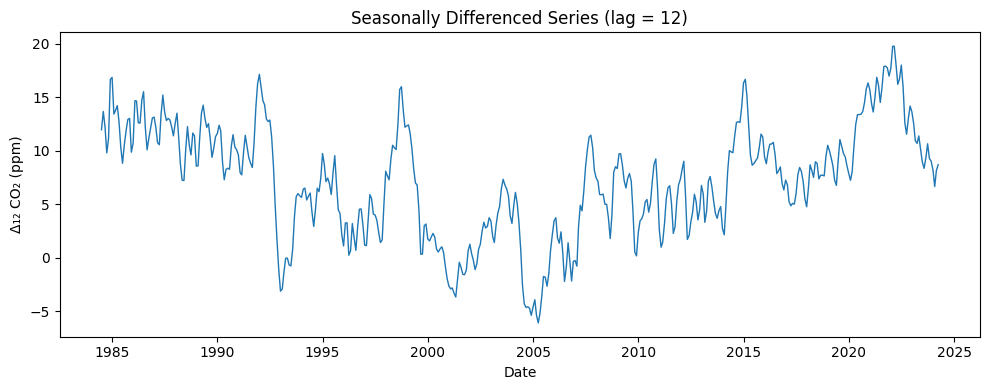

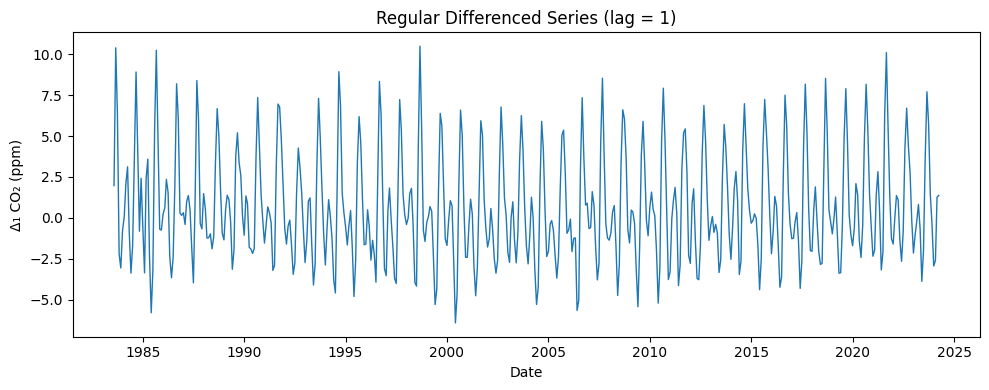

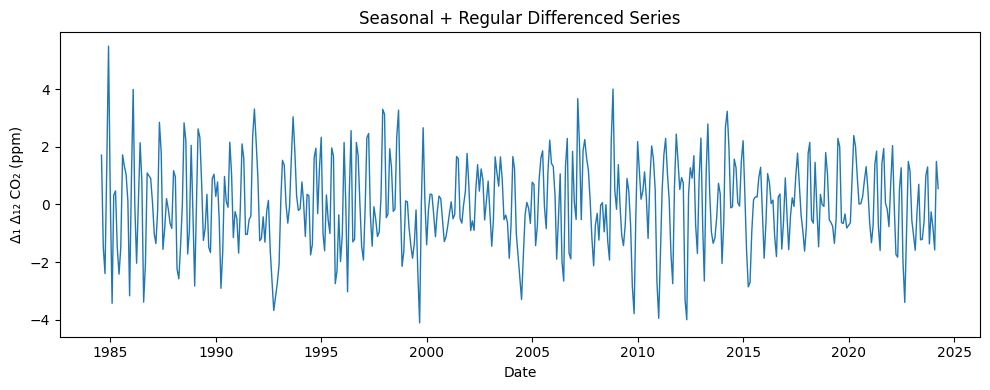

In [5]:
import matplotlib.pyplot as plt

# --- Seasonal differencing (lag 12) ---
train["diff_seasonal"] = train["average"].diff(12)

plt.figure(figsize=(10, 4))
plt.plot(train["diff_seasonal"], linewidth=1)
plt.title("Seasonally Differenced Series (lag = 12)")
plt.xlabel("Date")
plt.ylabel("Δ₁₂ CO₂ (ppm)")
plt.tight_layout()
plt.show()

# --- Regular differencing (lag 1) ---
train["diff_regular"] = train["average"].diff(1)

plt.figure(figsize=(10, 4))
plt.plot(train["diff_regular"], linewidth=1)
plt.title("Regular Differenced Series (lag = 1)")
plt.xlabel("Date")
plt.ylabel("Δ₁ CO₂ (ppm)")
plt.tight_layout()
plt.show()

# --- Combined differencing: seasonal + regular ---
train["diff_both"] = train["average"].diff(12).diff(1)

plt.figure(figsize=(10, 4))
plt.plot(train["diff_both"], linewidth=1)
plt.title("Seasonal + Regular Differenced Series")
plt.xlabel("Date")
plt.ylabel("Δ₁ Δ₁₂ CO₂ (ppm)")
plt.tight_layout()
plt.show()


In [6]:
# Step 2: ADF test & KPSS test of raw series

from statsmodels.tsa.stattools import adfuller, kpss

# Combined differenced series
diff_series = train["average"].diff(12).diff(1).dropna()

# Augmented Dickey-Fuller Test
adf_result = adfuller(diff_series)

print("Augmented Dickey-Fuller (ADF) Test")
print("----------------------------------")
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"Lags Used     : {adf_result[2]}")
print(f"Observations  : {adf_result[3]}")
print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

# KPSS Test
kpss_result = kpss(diff_series, regression='c', nlags='auto')

print("\n\nKPSS Test")
print("----------------")
print(f"KPSS Statistic : {kpss_result[0]:.4f}")
print(f"p-value        : {kpss_result[1]:.4f}")
print(f"Lags Used      : {kpss_result[2]}")
print("\nCritical Values:")
for key, value in kpss_result[3].items():
    print(f"   {key}: {value:.4f}")

Augmented Dickey-Fuller (ADF) Test
----------------------------------
ADF Statistic : -7.3127
p-value       : 0.0000
Lags Used     : 13
Observations  : 463

Critical Values:
   1%: -3.4446
   5%: -2.8678
   10%: -2.5701


KPSS Test
----------------
KPSS Statistic : 0.0377
p-value        : 0.1000
Lags Used      : 12

Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390


/var/folders/qy/441jwthx2_1g0zy86by2glkh0000gn/T/ipykernel_2154/1961808396.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(diff_series, regression='c', nlags='auto')


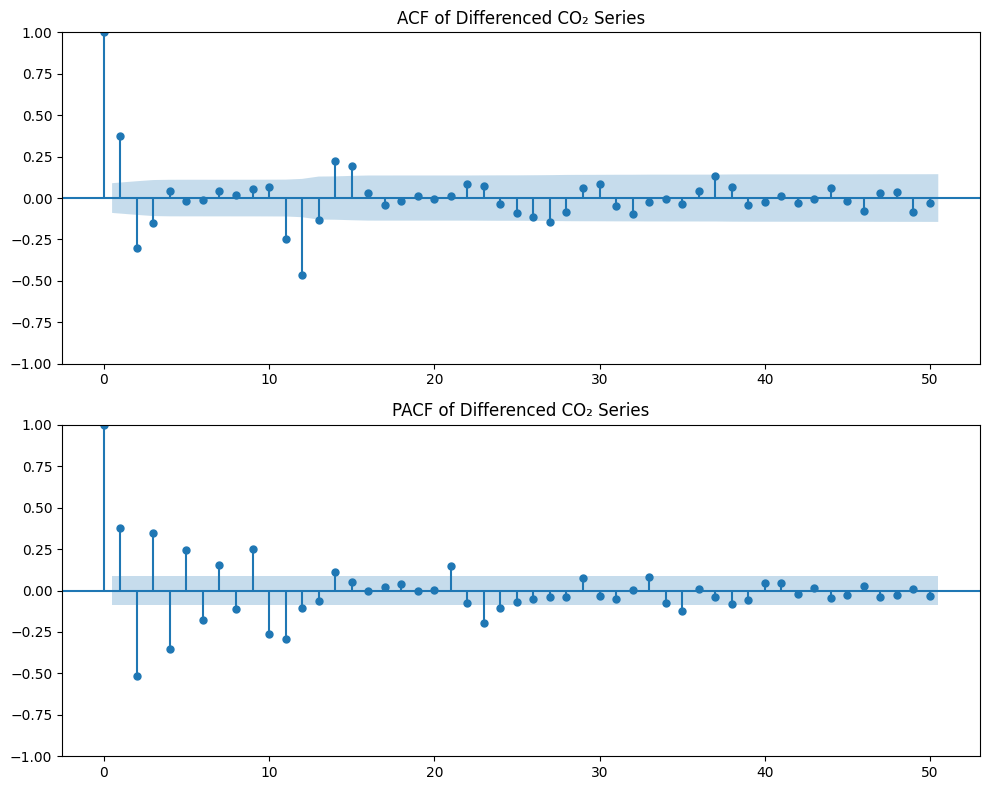

In [7]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Use the combined differenced series
diff_series = train["average"].diff(12).diff(1).dropna()

fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# ACF plot
plot_acf(diff_series, ax=ax[0], lags=50)
ax[0].set_title("ACF of Differenced CO₂ Series")

# PACF plot
plot_pacf(diff_series, ax=ax[1], lags=50, method="ywm")
ax[1].set_title("PACF of Differenced CO₂ Series")

plt.tight_layout()
plt.show()


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Raw series
y = train["average"]

# Fit SARIMA(3,1,0)x(1,1,0,12)
model = SARIMAX(
    y,
    order=(2, 1, 2),
    seasonal_order=(0, 1, 4, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
results = model.fit(disp=False)

print(results.summary())


                                           SARIMAX Results                                           
Dep. Variable:                                       average   No. Observations:                  490
Model:             SARIMAX(2, 1, 2)x(0, 1, [1, 2, 3, 4], 12)   Log Likelihood                -408.114
Date:                                       Tue, 18 Aug 2026   AIC                            834.228
Time:                                               15:00:27   BIC                            870.718
Sample:                                           07-01-1983   HQIC                           848.642
                                                - 04-01-2024                                         
Covariance Type:                                         opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3907     

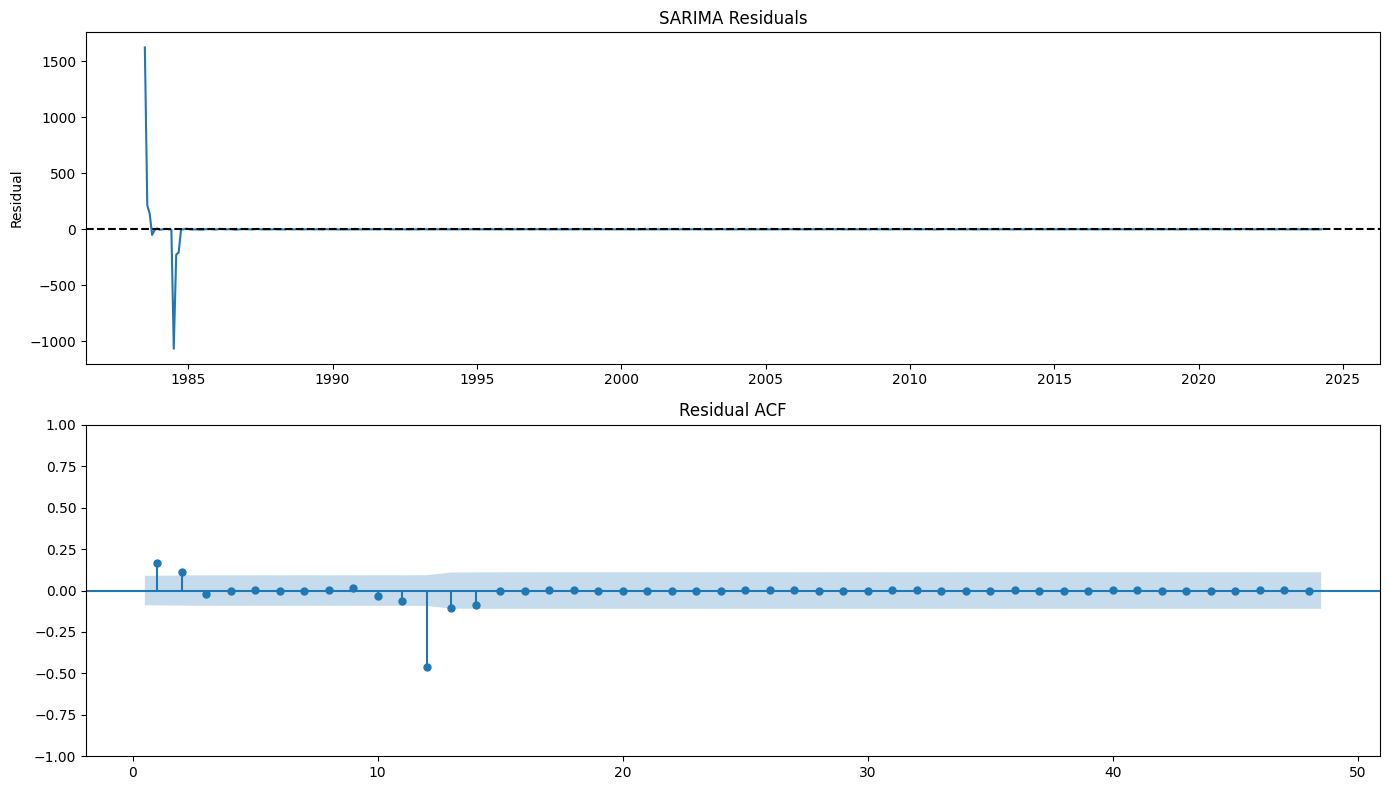

In [15]:
residuals = results.resid.dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Residual time series
axes[0].plot(residuals)
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_title("SARIMA Residuals")
axes[0].set_ylabel("Residual")

# Residual ACF
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(
    residuals,
    lags=48,
    ax=axes[1],
    zero=False
)

axes[1].set_title("Residual ACF")

plt.tight_layout()
plt.show()

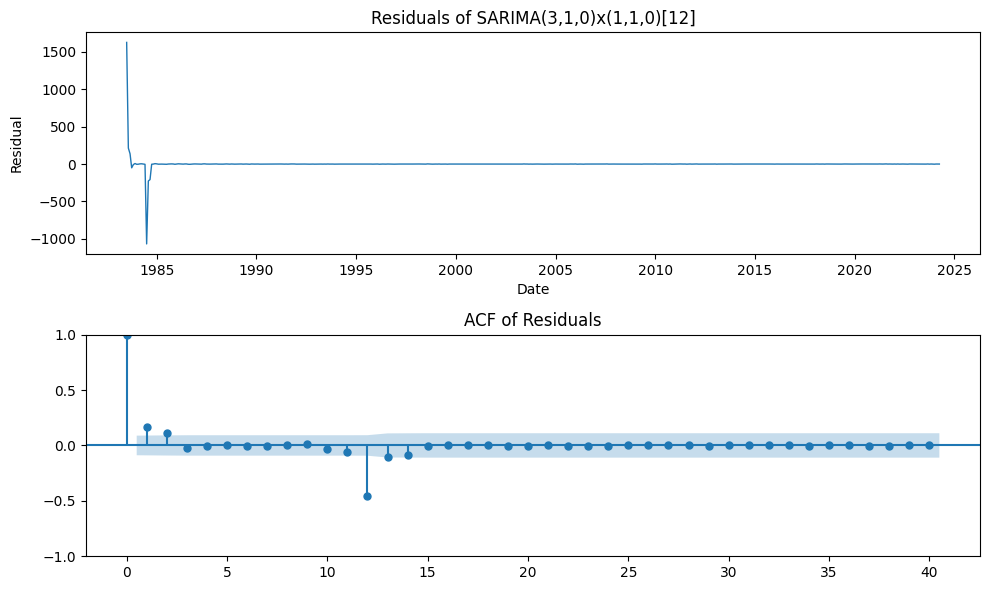

In [16]:
# --- Residual diagnostics (quick view) ---
resid = results.resid

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
ax[0].plot(resid, linewidth=1)
ax[0].set_title("Residuals of SARIMA(3,1,0)x(1,1,0)[12]")
ax[0].set_xlabel("Date")
ax[0].set_ylabel("Residual")

from statsmodels.graphics.tsaplots import plot_acf
plot_acf(resid.dropna(), ax=ax[1], lags=40)
ax[1].set_title("ACF of Residuals")

plt.tight_layout()
plt.show()


In [17]:
# --- 12-month ahead forecast on original scale ---
# Last observed date
last_date = y.index[-1]

# Create forecast index (next 12 months)
forecast_index = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=24,
    freq="MS"
)

# Get forecast and 95% CI
forecast_res = results.get_forecast(steps=24)
mean_forecast = forecast_res.predicted_mean
conf_int = forecast_res.conf_int(alpha=0.05)  # 95% CI

mean_forecast.index = forecast_index
conf_int.index = forecast_index

print(mean_forecast)
print(conf_int)


2024-05-01    1926.763393
2024-06-01    1923.084251
2024-07-01    1920.798422
2024-08-01    1924.682723
2024-09-01    1932.332568
2024-10-01    1937.460926
2024-11-01    1938.811702
2024-12-01    1937.963019
2025-01-01    1936.150023
2025-02-01    1935.467239
2025-03-01    1936.398587
2025-04-01    1937.070369
2025-05-01    1935.604856
2025-06-01    1931.968814
2025-07-01    1929.737286
2025-08-01    1933.498520
2025-09-01    1940.856836
2025-10-01    1945.832224
2025-11-01    1947.325124
2025-12-01    1946.552504
2026-01-01    1944.790215
2026-02-01    1944.170396
2026-03-01    1944.922739
2026-04-01    1945.522181
Freq: MS, Name: predicted_mean, dtype: float64
            lower average  upper average
2024-05-01    1925.546169    1927.980616
2024-06-01    1919.917366    1926.251136
2024-07-01    1916.513097    1925.083746
2024-08-01    1919.794026    1929.571420
2024-09-01    1926.808025    1937.857112
2024-10-01    1931.329890    1943.591963
2024-11-01    1932.169798    1945.453606
2

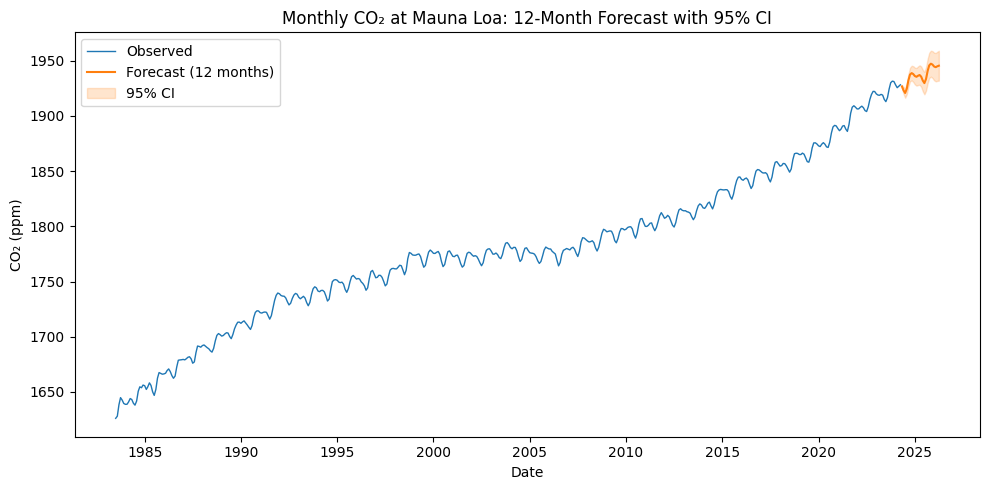

In [18]:
# --- Plot forecast vs raw series with 95% CI ---
plt.figure(figsize=(10, 5))

# Plot historical data
plt.plot(y, label="Observed", linewidth=1)

# Plot forecast
plt.plot(mean_forecast, label="Forecast (12 months)", color="C1")

# Plot confidence intervals
plt.fill_between(
    forecast_index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="C1",
    alpha=0.2,
    label="95% CI"
)

plt.title("Monthly CO₂ at Mauna Loa: 12-Month Forecast with 95% CI")
plt.xlabel("Date")
plt.ylabel("CO₂ (ppm)")
plt.legend()
plt.tight_layout()
plt.show()


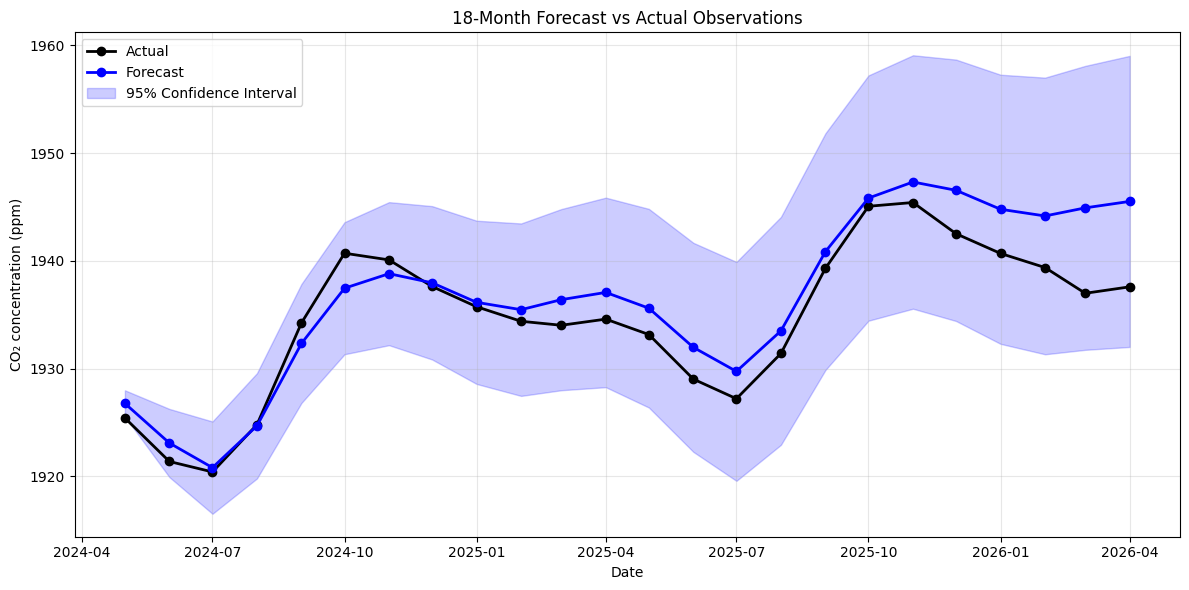

In [19]:
import matplotlib.pyplot as plt

# Actual values from the 18-month holdout period
actual = holdout["average"]

# Plot
plt.figure(figsize=(12, 6))

# Actual observed values
plt.plot(
    actual.index,
    actual,
    color="black",
    marker="o",
    linewidth=2,
    label="Actual"
)

# Forecast
plt.plot(
    mean_forecast.index,
    mean_forecast,
    color="blue",
    marker="o",
    linewidth=2,
    label="Forecast"
)

# 95% confidence interval
plt.fill_between(
    mean_forecast.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="blue",
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.xlabel("Date")
plt.ylabel("CO₂ concentration (ppm)")
plt.title("18-Month Forecast vs Actual Observations")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
from statsmodels.tsa.api import ExponentialSmoothing

model_triple = ExponentialSmoothing(
    train["average"], 
    seasonal_periods=12, 
    trend='add', 
    seasonal='add')

model_triple_fit = model_triple.fit()

In [21]:
forecast_triple = model_triple_fit.forecast(24)
print(forecast_triple)

2024-05-01    1926.979160
2024-06-01    1923.435190
2024-07-01    1921.004292
2024-08-01    1924.515993
2024-09-01    1932.158474
2024-10-01    1937.469416
2024-11-01    1938.919523
2024-12-01    1938.404772
2025-01-01    1937.255202
2025-02-01    1937.105963
2025-03-01    1938.200341
2025-04-01    1938.979945
2025-05-01    1937.739106
2025-06-01    1934.195135
2025-07-01    1931.764238
2025-08-01    1935.275939
2025-09-01    1942.918419
2025-10-01    1948.229362
2025-11-01    1949.679469
2025-12-01    1949.164717
2026-01-01    1948.015147
2026-02-01    1947.865908
2026-03-01    1948.960286
2026-04-01    1949.739891
Freq: MS, dtype: float64


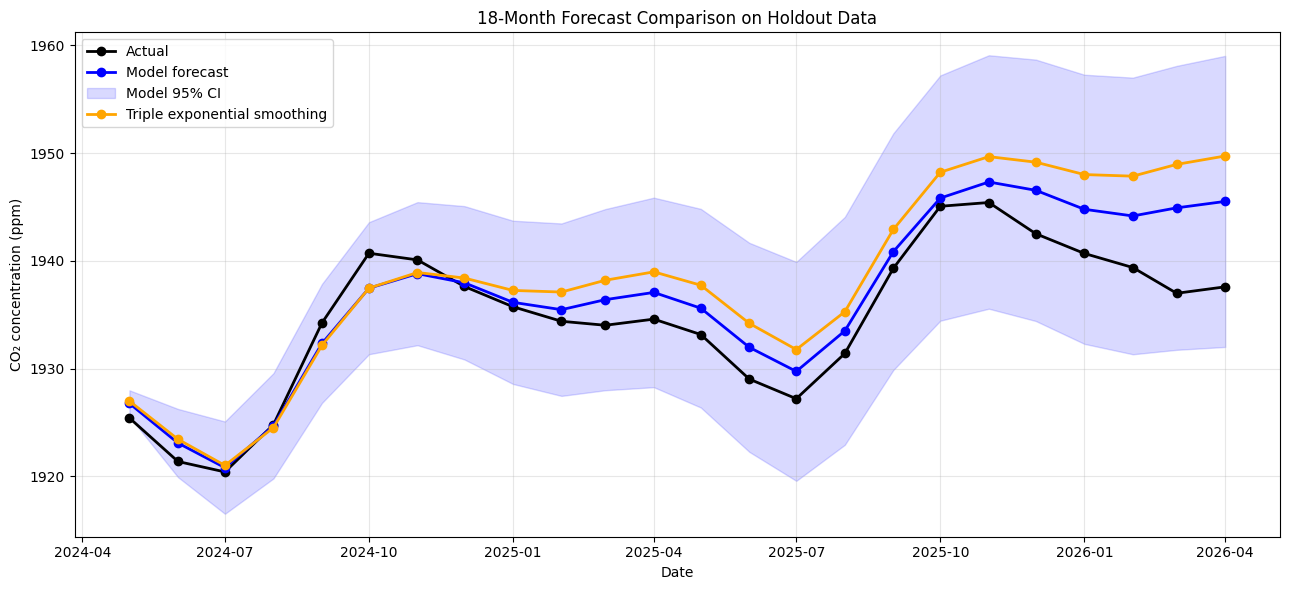

In [22]:
import matplotlib.pyplot as plt

# Actual observations in the 18-month holdout
actual = holdout["average"]

# Triple exponential smoothing forecast
forecast_triple = model_triple_fit.forecast(24)
forecast_triple.index = holdout.index

# Your other model's forecast
# Make sure its index also corresponds to the holdout period
mean_forecast.index = holdout.index
conf_int.index = holdout.index


# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(13, 6))

# Actual observed values
plt.plot(
    actual.index,
    actual,
    color="black",
    marker="o",
    linewidth=2,
    label="Actual"
)

# Model 1 forecast
plt.plot(
    mean_forecast.index,
    mean_forecast,
    color="blue",
    marker="o",
    linewidth=2,
    label="Model forecast"
)

# Model 1 95% CI
plt.fill_between(
    mean_forecast.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="blue",
    alpha=0.15,
    label="Model 95% CI"
)

# Triple exponential smoothing forecast
plt.plot(
    forecast_triple.index,
    forecast_triple,
    color="orange",
    marker="o",
    linewidth=2,
    label="Triple exponential smoothing"
)

plt.xlabel("Date")
plt.ylabel("CO₂ concentration (ppm)")
plt.title("18-Month Forecast Comparison on Holdout Data")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
comparison = pd.DataFrame({
    "Actual": holdout["average"],
    "Model_Forecast": mean_forecast,
    "Triple_Exp_Forecast": forecast_triple
})

print(comparison)

             Actual  Model_Forecast  Triple_Exp_Forecast
date                                                    
2024-05-01  1925.41     1926.763393          1926.979160
2024-06-01  1921.37     1923.084251          1923.435190
2024-07-01  1920.40     1920.798422          1921.004292
2024-08-01  1924.79     1924.682723          1924.515993
2024-09-01  1934.24     1932.332568          1932.158474
2024-10-01  1940.71     1937.460926          1937.469416
2024-11-01  1940.09     1938.811702          1938.919523
2024-12-01  1937.62     1937.963019          1938.404772
2025-01-01  1935.74     1936.150023          1937.255202
2025-02-01  1934.39     1935.467239          1937.105963
2025-03-01  1934.02     1936.398587          1938.200341
2025-04-01  1934.59     1937.070369          1938.979945
2025-05-01  1933.16     1935.604856          1937.739106
2025-06-01  1929.02     1931.968814          1934.195135
2025-07-01  1927.20     1929.737286          1931.764238
2025-08-01  1931.40     1933.49

In [24]:
comparison["Model_Error"] = (
    comparison["Actual"] - comparison["Model_Forecast"]
)

comparison["Triple_Error"] = (
    comparison["Actual"] - comparison["Triple_Exp_Forecast"]
)

print(comparison)

             Actual  Model_Forecast  Triple_Exp_Forecast  Model_Error  \
date                                                                    
2024-05-01  1925.41     1926.763393          1926.979160    -1.353393   
2024-06-01  1921.37     1923.084251          1923.435190    -1.714251   
2024-07-01  1920.40     1920.798422          1921.004292    -0.398422   
2024-08-01  1924.79     1924.682723          1924.515993     0.107277   
2024-09-01  1934.24     1932.332568          1932.158474     1.907432   
2024-10-01  1940.71     1937.460926          1937.469416     3.249074   
2024-11-01  1940.09     1938.811702          1938.919523     1.278298   
2024-12-01  1937.62     1937.963019          1938.404772    -0.343019   
2025-01-01  1935.74     1936.150023          1937.255202    -0.410023   
2025-02-01  1934.39     1935.467239          1937.105963    -1.077239   
2025-03-01  1934.02     1936.398587          1938.200341    -2.378587   
2025-04-01  1934.59     1937.070369          1938.9

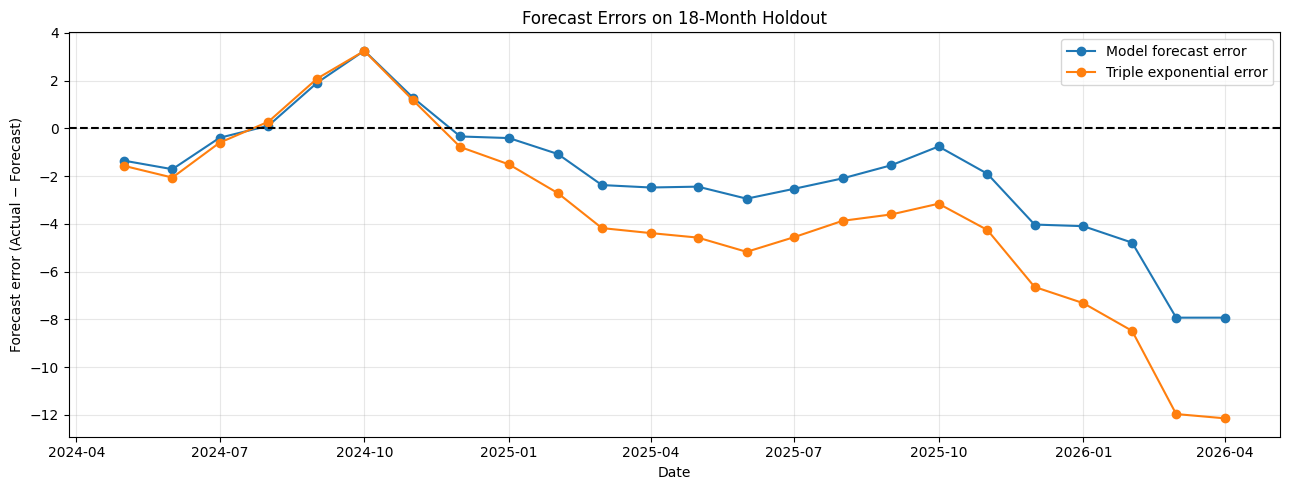

In [25]:
plt.figure(figsize=(13, 5))

plt.plot(
    comparison.index,
    comparison["Model_Error"],
    marker="o",
    label="Model forecast error"
)

plt.plot(
    comparison.index,
    comparison["Triple_Error"],
    marker="o",
    label="Triple exponential error"
)

plt.axhline(0, color="black", linestyle="--")

plt.ylabel("Forecast error (Actual − Forecast)")
plt.xlabel("Date")
plt.title("Forecast Errors on 18-Month Holdout")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
from sklearn.metrics import mean_absolute_error

mae_model = mean_absolute_error(
    comparison["Actual"],
    comparison["Model_Forecast"]
)

mae_triple = mean_absolute_error(
    comparison["Actual"],
    comparison["Triple_Exp_Forecast"]
)

print("Model MAE:", mae_model)
print("Triple exponential MAE:", mae_triple)

Model MAE: 2.4887115977463927
Triple exponential MAE: 4.18287812766017


In [27]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_model = np.sqrt(
    mean_squared_error(
        comparison["Actual"],
        comparison["Model_Forecast"]
    )
)

rmse_triple = np.sqrt(
    mean_squared_error(
        comparison["Actual"],
        comparison["Triple_Exp_Forecast"]
    )
)

print("Model RMSE:", rmse_model)
print("Triple exponential RMSE:", rmse_triple)

Model RMSE: 3.214626265455804
Triple exponential RMSE: 5.2276736140892295
